In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler 
from warnings import filterwarnings
filterwarnings('ignore')

In [20]:
df = pd.read_csv('Dataset/global_ai_jobs.csv')
df.head()

,id,country,job_role,ai_specialization,experience_level,experience_years,salary_usd,bonus_usd,education_required,industry,...,vacation_days,skill_demand_score,automation_risk,job_security_score,career_growth_score,work_life_balance_score,promotion_speed,salary_percentile,cost_of_living_index,employee_satisfaction
0,1,UAE,Machine Learning Engineer,Reinforcement Learning,Entry,0,66465,5395,Master,Automotive,...,27,12,76,57,65,73,15,55,1.23,76
1,2,USA,AI Engineer,LLM,Entry,1,75507,11713,Bootcamp,Retail,...,27,54,29,69,60,51,15,58,0.87,67
2,3,Brazil,Research Scientist,Analytics,Entry,0,41660,5268,PhD,Healthcare,...,13,12,49,70,59,68,37,13,2.13,61
3,4,India,Software Engineer AI,Computer Vision,Senior,6,43268,7975,Diploma,Tech,...,30,80,47,79,65,55,46,74,1.49,56
4,5,Germany,Machine Learning Engineer,Computer Vision,Entry,0,69119,4758,Master,Retail,...,24,82,47,64,52,69,17,21,0.87,72


In [21]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 90000 entries, 0 to 89999
Data columns (total 35 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       90000 non-null  int64  
 1   country                  90000 non-null  str    
 2   job_role                 90000 non-null  str    
 3   ai_specialization        90000 non-null  str    
 4   experience_level         90000 non-null  str    
 5   experience_years         90000 non-null  int64  
 6   salary_usd               90000 non-null  int64  
 7   bonus_usd                90000 non-null  int64  
 8   education_required       90000 non-null  str    
 9   industry                 90000 non-null  str    
 10  company_size             90000 non-null  str    
 11  interview_rounds         90000 non-null  int64  
 12  year                     90000 non-null  int64  
 13  work_mode                90000 non-null  str    
 14  weekly_hours             90000 no

In [22]:
df.describe()

,id,experience_years,salary_usd,bonus_usd,interview_rounds,year,weekly_hours,company_rating,job_openings,hiring_difficulty_score,...,vacation_days,skill_demand_score,automation_risk,job_security_score,career_growth_score,work_life_balance_score,promotion_speed,salary_percentile,cost_of_living_index,employee_satisfaction
count,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,...,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000
mean,45000.500000,7.028133,96546.249222,13028.418722,4.495689,2023.003200,45.476268,3.998004,17.521867,55.028604,...,19.986367,50.461200,50.357544,75.563533,57.198544,69.146478,38.439633,50.542411,1.503042,72.733100
std,25980.906451,5.889327,43935.479553,7886.738085,1.704553,2.002624,5.475497,0.461914,7.848576,17.901451,...,6.069607,28.853798,28.845671,11.316485,12.900225,13.213996,18.429221,28.891570,0.576449,8.124018
min,1.000000,0.000000,28000.000000,1404.000000,2.000000,2020.000000,36.000000,3.200000,1.000000,0.000000,...,10.000000,1.000000,1.000000,29.000000,25.000000,25.000000,12.000000,1.000000,0.500000,42.000000
25%,22500.750000,2.000000,64676.750000,7104.750000,3.000000,2021.000000,40.700000,3.600000,12.000000,42.881134,...,15.000000,25.000000,25.000000,68.000000,48.000000,59.000000,24.000000,25.000000,1.010000,67.000000
50%,45000.500000,6.000000,87544.000000,11279.000000,4.000000,2023.000000,45.500000,4.000000,17.000000,55.066089,...,20.000000,51.000000,50.000000,77.000000,57.000000,69.000000,37.000000,51.000000,1.510000,73.000000
75%,67500.250000,12.000000,123906.000000,16997.250000,6.000000,2025.000000,50.200000,4.400000,23.000000,67.118119,...,25.000000,75.000000,75.000000,84.000000,66.000000,79.000000,51.000000,76.000000,2.000000,78.000000
max,90000.000000,19.000000,300622.000000,57681.000000,7.000000,2026.000000,55.000000,4.800000,50.000000,100.000000,...,30.000000,100.000000,100.000000,99.000000,99.000000,98.000000,98.000000,100.000000,2.500000,99.000000


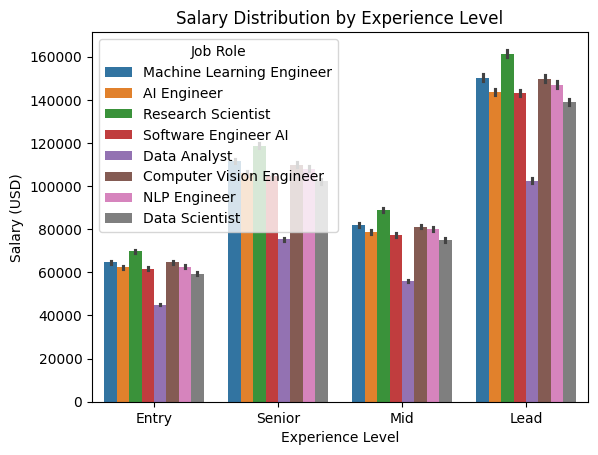

In [23]:
# Analysis of salary with the experience level
sns.barplot(
    x='experience_level',
    y='salary_usd',
    hue='job_role',
    data=df)
plt.title('Salary Distribution by Experience Level')
plt.xlabel('Experience Level')
plt.ylabel('Salary (USD)')
plt.legend(title='Job Role')
plt.show()

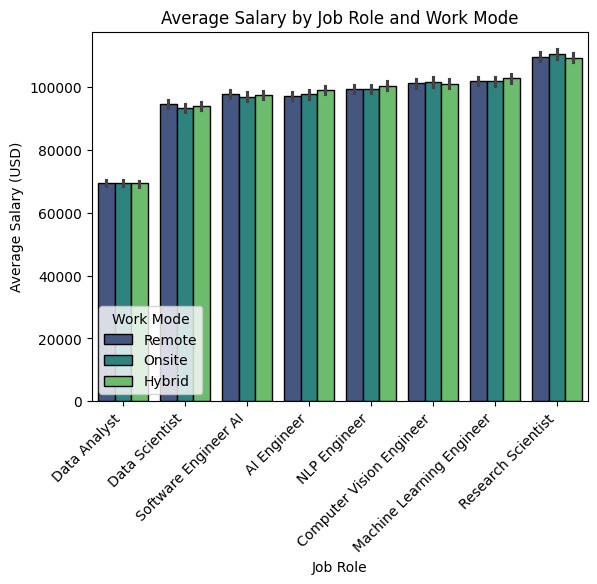

In [24]:
# Analysis of salary of different jobs in different work mode
order = df.groupby('job_role')['salary_usd'].mean().sort_values(ascending=True).index
sns.barplot(
    x='job_role',
	y='salary_usd',
	hue='work_mode',
	data=df,
    order=order,
	palette='viridis',
	edgecolor='black',
)
plt.title('Average Salary by Job Role and Work Mode')
plt.xlabel('Job Role')
plt.ylabel('Average Salary (USD)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Work Mode')
plt.show()

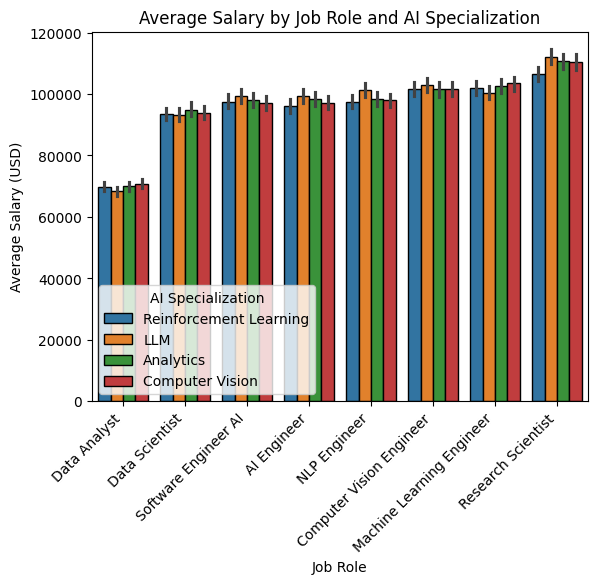

In [25]:
order = df.groupby('job_role')['salary_usd'].mean().sort_values(ascending=True).index
top_ai_spcial = df['ai_specialization'].value_counts().head(4).index
sns.barplot(
    x='job_role',
    y='salary_usd',
    hue='ai_specialization',
    order=order,
    data=df[df['ai_specialization'].isin(top_ai_spcial)],
    edgecolor='black')
plt.title('Average Salary by Job Role and AI Specialization')
plt.xlabel('Job Role')
plt.ylabel('Average Salary (USD)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='AI Specialization')
plt.show()

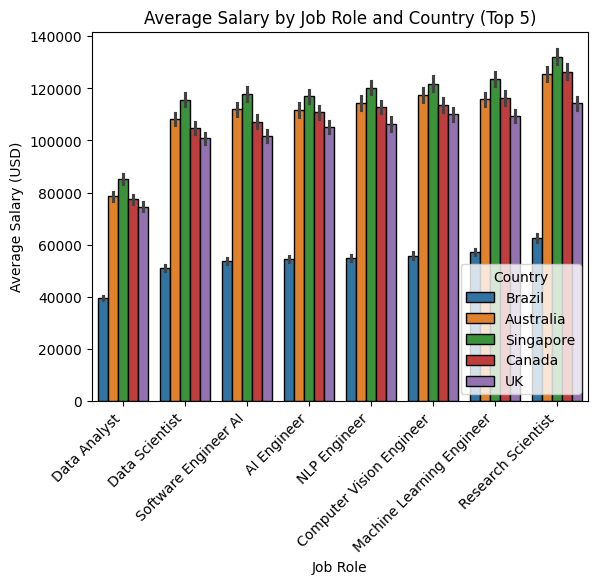

In [26]:
order = df.groupby('job_role')['salary_usd'].mean().sort_values(ascending=True).index
top_countries = df['country'].value_counts().head(5).index
sns.barplot(
    x='job_role',
    y='salary_usd',
    hue='country',
    order=order,
    data=df[df['country'].isin(top_countries)],
    edgecolor='black'
)
plt.title('Average Salary by Job Role and Country (Top 5)')
plt.xlabel('Job Role')
plt.ylabel('Average Salary (USD)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Country')
plt.show()

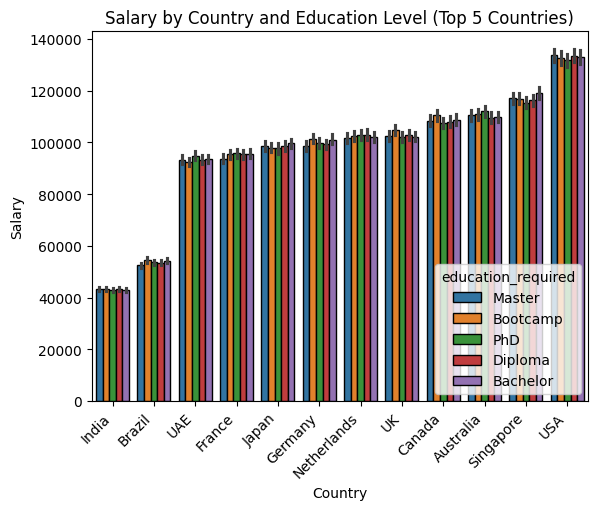

In [27]:
order = df.groupby('country')['salary_usd'].mean().sort_values(ascending=True).index
top_education = df['education_required'].value_counts().head(5).index
sns.barplot(
    x='country',
    y='salary_usd',
    hue='education_required',
    order=order,
    data=df[df['education_required'].isin(top_education)],
    edgecolor='black',
)
plt.xticks(rotation=45, ha='right')
plt.title("Salary by Country and Education Level (Top 5 Countries)")
plt.xlabel('Country')
plt.ylabel('Salary')
plt.show()

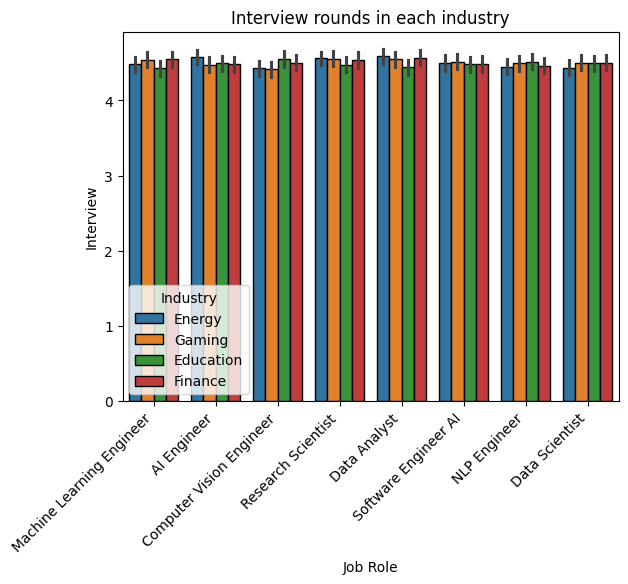

In [28]:
top_industry = df['industry'].value_counts().head(4).index
sns.barplot(
    x='job_role',
    y='interview_rounds',
    data=df[df['industry'].isin(top_industry)],
    hue='industry',
    edgecolor='black')
plt.title('Interview rounds in each industry')
plt.xlabel('Job Role')
plt.ylabel('Interview')
plt.legend(title='Industry')
plt.xticks(rotation=45, ha='right')
plt.show()

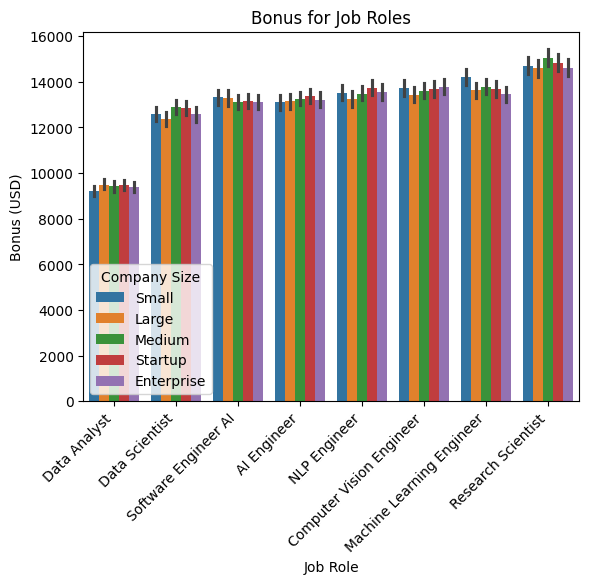

In [29]:
order = df.groupby('job_role')['bonus_usd'].mean().sort_values(ascending=True).index
sns.barplot(
    x='job_role',
    y='bonus_usd',
    data=df,
    order=order,
    hue='company_size'
)
plt.title('Bonus for Job Roles')
plt.xlabel('Job Role')
plt.ylabel('Bonus (USD)')
plt.legend(title='Company Size')
plt.xticks(rotation=45, ha='right')
plt.show()

In [30]:
# OneHot-Encoding for Nominal Features
nominal_features = ['country', 'job_role', 'ai_specialization', 'industry', 'work_mode', 'education_required']
onehot_encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
encoded_data = onehot_encoder.fit_transform(df[nominal_features])
encoded_df = pd.DataFrame(encoded_data, columns=onehot_encoder.get_feature_names_out(nominal_features), index=df.index)
df = pd.concat([df.drop(columns=nominal_features), encoded_df], axis=1)

In [31]:
# Ordinal-Encoding for Ordinal Features
ordinal_features1 = OrdinalEncoder(categories=[['Entry', 'Mid', 'Senior', 'Lead']])
ordinal_features2 = OrdinalEncoder(categories=[['Startup', 'Small', 'Medium', 'Large', 'Enterprise']])
df['experience_level'] = ordinal_features1.fit_transform(df[['experience_level']])
df['company_size'] = ordinal_features2.fit_transform(df[['company_size']])

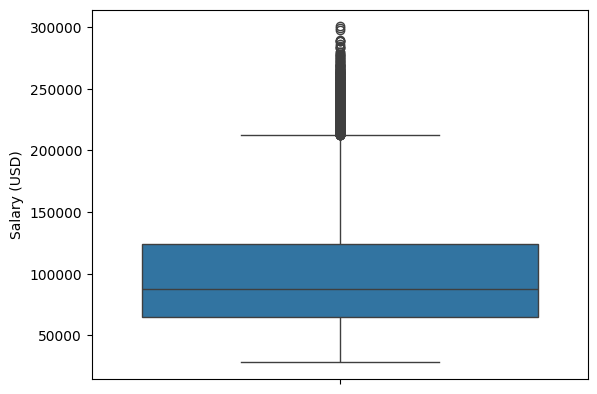

In [32]:
# Analyzing Salary
sns.boxplot(df['salary_usd'])
plt.ylabel('Salary (USD)')
plt.show()

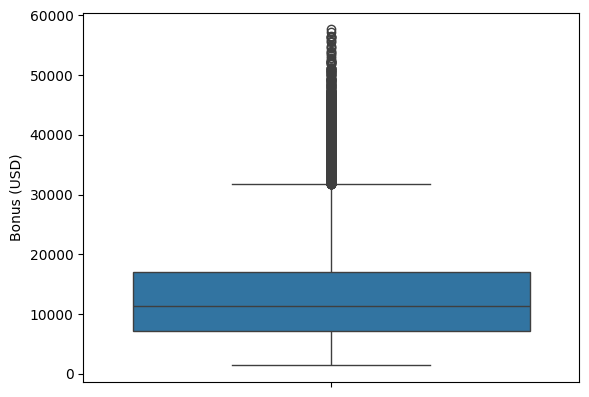

In [33]:
# Analyzing Bonus
sns.boxplot(df['bonus_usd'])
plt.ylabel('Bonus (USD)')
plt.show()

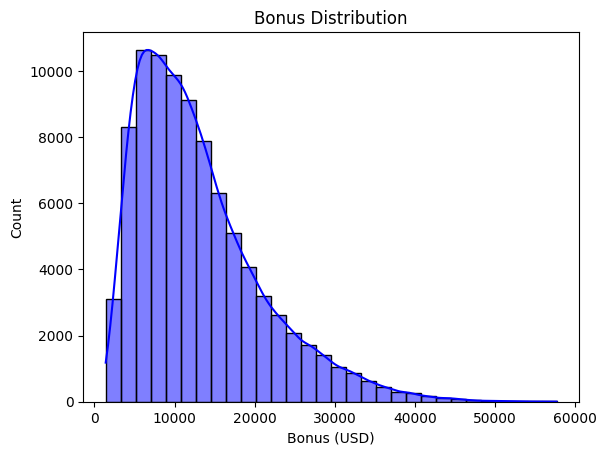

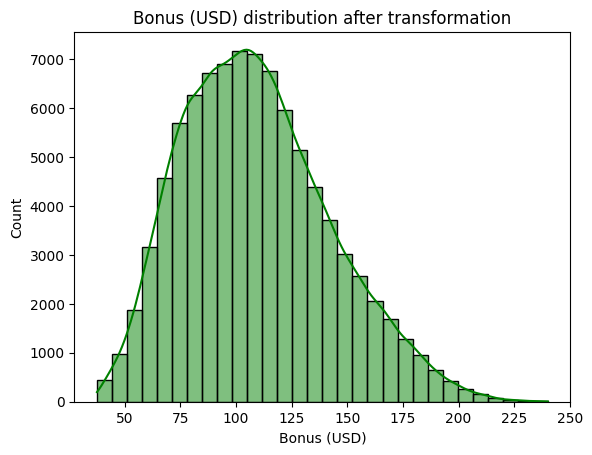

In [34]:
# Analyzing the distribution of Bonus
sns.histplot(df['bonus_usd'], bins=30, kde=True, color='blue')
plt.title('Bonus Distribution')
plt.xlabel('Bonus (USD)')
plt.show()

# Analyzing the distribution of Bonus after transformation
df['bonus_usd'] = np.sqrt(df['bonus_usd'])
plt.title('Bonus (USD) distribution after transformation')
plt.xlabel('Bonus (USD)')
sns.histplot(x='bonus_usd', data=df, bins=30, color='green',kde=True)
plt.show()

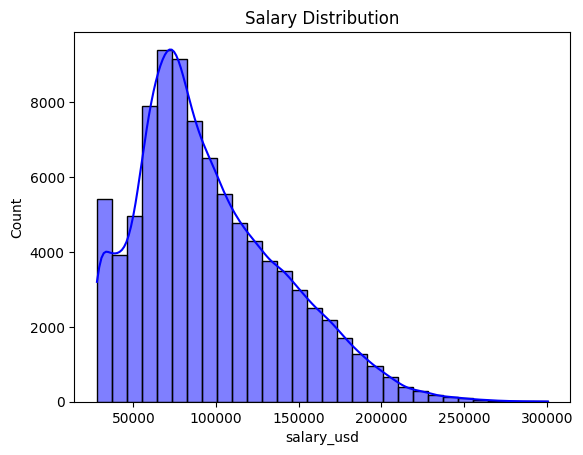

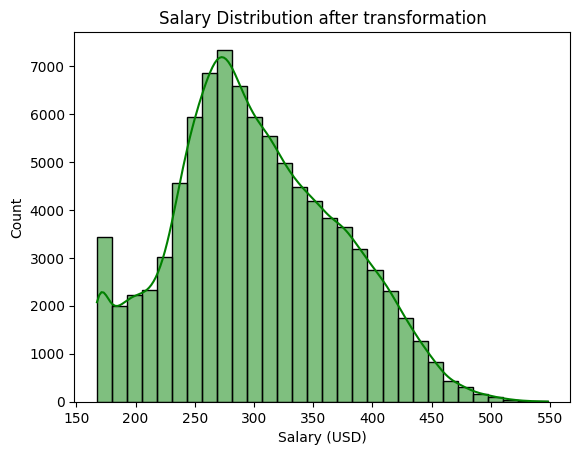

In [35]:
# Analyzing the distribution of Salary
sns.histplot(x='salary_usd', data=df, bins=30, color='blue', kde=True)
plt.title('Salary Distribution')
plt.show()

# Distribution of Salary after transformation
df['log_salary'] = np.sqrt(df['salary_usd'])
plt.title('Salary Distribution after transformation')
plt.xlabel('Salary (USD)')
sns.histplot(x='log_salary', data=df, color='green', bins=30, kde=True)
plt.show()